## Лекція 2. Дерева рішень і випадковий ліс

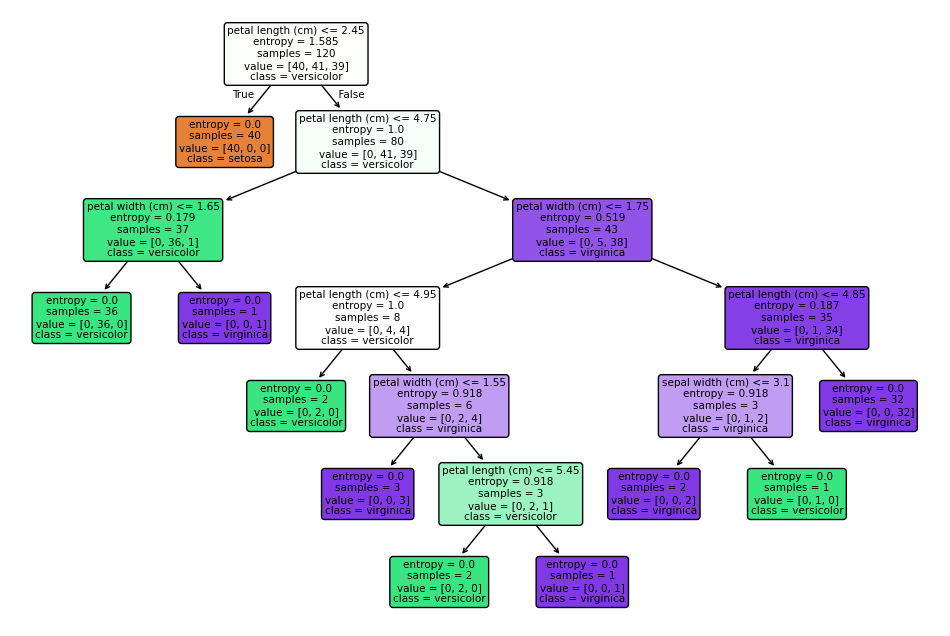

Decision Tree Accuracy: 1.0


In [1]:
# Import necessery libraries
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Load the iris dataset
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42)

# Create a decision tree model
dt_model = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions
y_pred = dt_model.predict(X_test)

# Visualize the decision tree
plt.figure(figsize=(12, 8))
plot_tree(dt_model, feature_names=iris.feature_names, class_names=iris.target_names, filled=True, rounded=True)
plt.show()

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {accuracy}")

In [2]:
dt_model.__dict__

{'criterion': 'entropy',
 'splitter': 'best',
 'max_depth': None,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'min_weight_fraction_leaf': 0.0,
 'max_features': None,
 'max_leaf_nodes': None,
 'random_state': 42,
 'min_impurity_decrease': 0.0,
 'class_weight': None,
 'ccp_alpha': 0.0,
 'monotonic_cst': None,
 'n_features_in_': 4,
 'n_outputs_': 1,
 'classes_': array([0, 1, 2]),
 'n_classes_': np.int64(3),
 'max_features_': 4,
 'tree_': <sklearn.tree._tree.Tree at 0x2c8f3e77e50>}

In [3]:
from sklearn.datasets import load_iris

iris = load_iris()
sepal_length = iris.data[:, 0]  # Sepal length is the first feature
target = iris.target

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(sepal_length, target, test_size=0.2, random_state=42)

In [4]:
total_samples = len(y_train)
class_counts = {class_label: sum(y_train == class_label) for class_label in set(y_train)}
prior_probabilities = {class_label: count / total_samples for class_label, count in class_counts.items()}
prior_probabilities

{np.int64(0): np.float64(0.3333333333333333),
 np.int64(1): np.float64(0.3416666666666667),
 np.int64(2): np.float64(0.325)}

In [5]:
class_counts

{np.int64(0): np.int64(40),
 np.int64(1): np.int64(41),
 np.int64(2): np.int64(39)}

In [6]:
class_counts.items()

dict_items([(np.int64(0), np.int64(40)), (np.int64(1), np.int64(41)), (np.int64(2), np.int64(39))])

In [7]:
prior_probabilities

{np.int64(0): np.float64(0.3333333333333333),
 np.int64(1): np.float64(0.3416666666666667),
 np.int64(2): np.float64(0.325)}

In [8]:
X_train

array([4.6, 5.7, 6.7, 4.8, 4.4, 6.3, 6.4, 5.2, 5. , 5.2, 5.8, 6. , 6.7,
       5.4, 5.4, 5.5, 6.3, 6.4, 6.6, 7.2, 5.7, 7.6, 5.6, 5.1, 7.7, 5.8,
       5.2, 5. , 5.1, 5. , 6.3, 4.8, 5. , 5.1, 5.6, 5.1, 5.7, 7.7, 4.6,
       6.2, 5.7, 5.5, 6. , 5.8, 6. , 5.4, 6.2, 5.5, 5.4, 5. , 6.4, 5. ,
       5. , 5.5, 6.7, 4.9, 5.8, 5. , 5. , 5.9, 5.1, 6.9, 6. , 6.1, 7.7,
       5.5, 4.4, 4.3, 6. , 7.2, 4.6, 5.1, 4.4, 6.3, 6.3, 4.6, 6.8, 6.3,
       4.7, 6.1, 6.5, 6.2, 7. , 6.4, 5.1, 6.9, 5.9, 6.5, 5.7, 5.2, 6.1,
       4.5, 6.6, 5.5, 5.3, 5.6, 7.3, 6.7, 5.1, 4.9, 6.7, 7.2, 4.9, 6.7,
       4.9, 6.9, 7.4, 6.3, 5.7, 6.5, 6.3, 6.4, 5.6, 5.9, 5.4, 6.1, 4.9,
       5.8, 5.8, 7.1])

In [9]:
from scipy.stats import norm
likehoods = {class_label: norm.pdf(X_train, loc=X_train[y_train == class_label].mean(), scale=X_train[y_train == class_label].std()) for class_label in set(y_train)}

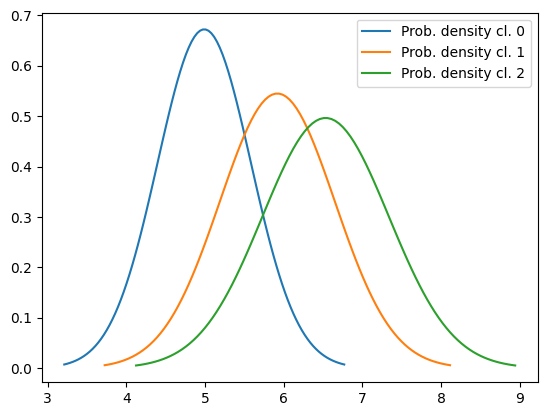

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import math

for class_label in set(y_train):
    mu = X_train[y_train == class_label].mean()
    variance = X_train[y_train == class_label].std()
    sigma = math.sqrt(variance)
    x = np.linspace(mu - 3 * sigma, mu + 3 * sigma, 100)
    plt.plot(x, stats.norm.pdf(x, mu, sigma), label=f'Prob. density cl. {class_label}')
plt.legend()
plt.show()    

In [11]:
X_train[0]

np.float64(4.6)

In [12]:
likehoods[0][0], likehoods[1][0], likehoods[2][0]

(np.float64(0.6134848307960548),
 np.float64(0.03584106735857552),
 np.float64(0.006961535714191303))

In [13]:
# a-priori probabilities vs. posteriori probabilities - to make a more confident prediction regarding thru class
print(f'a-priori probabilities', prior_probabilities)
posterior_probabilities =_0 = {0: likehoods[0][0], 1: likehoods[1][0], 2: likehoods[2][0]}
print(f'a-posteriori probabilities', posterior_probabilities)

a-priori probabilities {np.int64(0): np.float64(0.3333333333333333), np.int64(1): np.float64(0.3416666666666667), np.int64(2): np.float64(0.325)}
a-posteriori probabilities {0: np.float64(0.6134848307960548), 1: np.float64(0.03584106735857552), 2: np.float64(0.006961535714191303)}


#### Splitting the features on imformation gain

In [14]:
# Load the iris target
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42)

In [15]:
# Entropy of the a-priori probobilities distribution of versicolor classes (1), one vs. rest
total_samples = len(y_train)

pred_versicolor = np.array([1 if class_ == 1 else 0 for class_ in y_train])
class_counts_versicolor = {class_label: sum(pred_versicolor == class_label) for class_label in set(pred_versicolor)}
prior_probabilities_versicolor = {class_label: count / total_samples for class_label, count in class_counts_versicolor.items()}

prior_probabilities_array_versicolor = np.array([prob for key, prob in prior_probabilities_versicolor.items()])
entropy_ = -np.sum(prior_probabilities_array_versicolor * np.log(prior_probabilities_array_versicolor))
entropy_

np.float64(0.6421347837839517)

In [16]:
prior_probabilities_array_versicolor

array([0.65833333, 0.34166667])

In [17]:
# equivalent
from scipy.stats import entropy
entropy(prior_probabilities_array_versicolor)

np.float64(0.6421347837839517)

In [20]:
# Entropy conditional on the petal lengh <= 2.45, for class versicolor
petal_lenghs = X_train[:, 2]
pet_len_smaller_than_2_45 = np.array([1 if p_l <= 2.45 else 0 for p_l in petal_lenghs])

In [21]:
pet_len_smaller_than_2_45

array([1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0])

In [22]:
class_probs_petal_lenth = np.array([(total_samples - np.sum(pet_len_smaller_than_2_45)) / total_samples, (np.sum(pet_len_smaller_than_2_45))])
class_probs_petal_lenth

array([ 0.66666667, 40.        ])

In [23]:
import numpy.ma as ma
group_1 = ma.masked_where(pet_len_smaller_than_2_45 == 1, pet_len_smaller_than_2_45).mask
group_2 = ma.masked_where(pet_len_smaller_than_2_45 == 0, pet_len_smaller_than_2_45).mask

In [24]:
len(pet_len_smaller_than_2_45[group_1])

40

In [25]:
pred_versicolor[group_2]

array([1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0])

In [26]:
len(pred_versicolor[group_2]) - np.sum(pred_versicolor[group_2])

np.int64(39)

In [27]:
len(pred_versicolor[group_2])

80

In [39]:
total_samples_group_1 = len(pet_len_smaller_than_2_45[group_1])
class_probs_versicolor_group_1 = np.array([(total_samples_group_1 - np.sum(pred_versicolor[group_2])) / total_samples_group_1, (np.sum(pred_versicolor[group_2])) / total_samples_group_1])
entropy_versicolor_group_1 = entropy(class_probs_versicolor_group_1)
class_probs_versicolor_group_1, "Entropy", entropy_versicolor_group_1

(array([-0.025,  1.025]), 'Entropy', np.float64(-inf))

In [40]:
pred_versicolor[group_1]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [41]:
pred_versicolor

array([0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 0])

In [42]:
np.sum(pred_versicolor[group_1])

np.int64(0)

In [43]:
total_samples_group_2 = len(pet_len_smaller_than_2_45[group_2])
class_probs_versicolor_group_2 = np.array([(total_samples_group_2 - np.sum(pred_versicolor[group_2])) / total_samples_group_2, (np.sum(pred_versicolor[group_2])) / total_samples_group_2])
entropy_versicolor_group_2 = entropy(class_probs_versicolor_group_2)
class_probs_versicolor_group_2, "Entropy", entropy_versicolor_group_2

(array([0.4875, 0.5125]), 'Entropy', np.float64(0.6928346479997213))

In [44]:
entropy(np.array([41/80, 39/80])) * class_probs_petal_lenth[1]

np.float64(27.713385919988852)

In [46]:
entropy_conditional = (class_probs_petal_lenth[0] * entropy_versicolor_group_1) + (class_probs_petal_lenth[1] * entropy_versicolor_group_2)
entropy_conditional

np.float64(-inf)

In [47]:
i_gain = entropy_ - entropy_conditional
i_gain

np.float64(inf)

In [48]:
from sklearn.feature_selection import mutual_info_classif
mutual_info_classif(pet_len_smaller_than_2_45.reshape(-1, 1), pred_versicolor)

array([0.17195983])

In [49]:
pred_versicolor

array([0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 0])

### Random forest: Making predictions more robust